In [36]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [37]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(os.path.dirname(script_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [38]:
# load old sheets

root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
latent_array = joblib.load(os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
# df_clean = pd.read_csv(os.path.join(root_dir, 'label_20260223_combined_lat8.csv'))

df_clean = pd.read_csv(os.path.join(root_dir, 'label_20260223_combined_lat8_equalweight.csv'))


In [39]:
patch_label_df

,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,...,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,group,unique_ID
0,0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,3470.368164,...,4.793272,20.604002,5.372108,-7.815341,1.760113,32.959721,-21.882824,2.258103,control,control-f0000x0080y0816ps32.tif
1,1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,2753.338867,...,0.826394,-3.398712,-2.768886,5.473682,-1.714877,1.444764,-5.044192,-2.793007,control,control-f0000x0112y0784ps32.tif
2,2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134788,1.867131,0,0,4177.766602,...,10.628540,3.866692,-0.625196,2.456605,0.941578,6.303121,-6.728461,-7.896038,control,control-f0000x0144y0784ps32.tif
3,3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,3782.319336,...,13.097126,9.377098,7.463983,-0.638954,3.322603,22.364613,-18.249426,0.339599,control,control-f0000x0176y0784ps32.tif
4,4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,3487.683594,...,15.051421,4.962876,1.968619,4.266151,3.475077,12.175271,-11.814137,-9.985755,control,control-f0000x0240y0752ps32.tif
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,4753.446289,...,-4.928203,4.098186,-5.373686,4.427641,-0.110387,9.007499,-16.987860,-2.702754,ycomp,ycomp-f0040x0912y0624ps32.tif
23652,23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,8459.265625,...,9.884430,6.437505,1.430342,7.115860,2.850735,12.949064,-10.358782,-3.006688,ycomp,ycomp-f0040x0912y0656ps32.tif
23653,23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,7675.988281,...,1.726854,-1.704976,-4.656003,1.686419,1.671660,7.410644,-7.135116,-0.333692,ycomp,ycomp-f0040x0912y0688ps32.tif
23654,23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,5432.383789,...,0.885759,-2.416347,-6.106094,3.669299,-1.798731,8.590202,-13.161478,-6.561848,ycomp,ycomp-f0040x0912y0720ps32.tif


In [65]:
import numpy as np
import pandas as pd


def predict_all_samples(
    patch_label_df: pd.DataFrame,
    lat_features,
    clf_or_bundle,
    pred_col_name,
    use_tau_adjustment=True,
    tau=None,
):
    """
    Predict labels for all samples, with optional tau-based prior adjustment.

    Parameters
    ----------
    patch_label_df : pd.DataFrame
        DataFrame containing feature columns.
    lat_features : list
        List of feature column names to use.
    clf_or_bundle :
        Either:
          1) trained classifier with predict() / predict_proba(), or
          2) dict bundle with keys:
             - "model"
             - "classes"
             - "priors"
             - "tau"
    pred_col_name : str
        Name of prediction column to add.
    use_tau_adjustment : bool
        Whether to apply prior-adjusted multiclass prediction.
    tau : float or None
        If provided, overrides tau from bundle.

    Returns
    -------
    out : pd.DataFrame
        Copy of input DataFrame with predictions and probabilities added.
    """
    # --------------------------------------------------
    # 1) Build feature matrix
    # --------------------------------------------------
    X = patch_label_df[lat_features].copy()
    X = X.apply(pd.to_numeric, errors="coerce")

    # optional safety check
    if X.isnull().any().any():
        raise ValueError("Some feature values became NaN after numeric conversion.")

    # --------------------------------------------------
    # 2) Parse classifier / bundle
    # --------------------------------------------------
    if isinstance(clf_or_bundle, dict):
        clf = clf_or_bundle["model"]
        classes = np.asarray(clf_or_bundle["classes"])
        priors = np.asarray(clf_or_bundle["priors"], dtype=float)
        tau_final = clf_or_bundle.get("tau", 0.0) if tau is None else tau
    else:
        clf = clf_or_bundle
        tau_final = 0.0 if tau is None else tau

        # infer classes from classifier if possible
        if hasattr(clf, "classes_"):
            classes = np.asarray(clf.classes_)
        else:
            raise ValueError(
                "Classifier does not expose classes_. Pass a saved bundle instead."
            )

        # if no priors are supplied, tau adjustment cannot be applied safely
        priors = None

    out = patch_label_df.copy()

    # --------------------------------------------------
    # 3) Predict
    # --------------------------------------------------
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)  # shape: (N, C)

        # Use tau-adjusted prediction if requested and priors available
        if use_tau_adjustment and (tau_final is not None) and (tau_final > 0):
            if priors is None:
                raise ValueError(
                    "Tau adjustment requested, but priors are unavailable. "
                    "Pass the saved bundle with priors."
                )

            adjusted_scores = np.log(proba + 1e-12) - tau_final * np.log(priors + 1e-12)
            pred_idx = np.argmax(adjusted_scores, axis=1)
            y_pred = classes[pred_idx]

            out[pred_col_name] = y_pred
            out["pred_max_proba"] = np.max(proba, axis=1)
            out["pred_max_adjusted_score"] = np.max(adjusted_scores, axis=1)

            # store original per-class probabilities
            for i, c in enumerate(classes):
                out[f"proba_class{c}"] = proba[:, i]

            # optionally store adjusted scores too
            for i, c in enumerate(classes):
                out[f"adjusted_score_class{c}"] = adjusted_scores[:, i]

        else:
            # plain prediction
            y_pred = clf.predict(X)
            out[pred_col_name] = y_pred
            out["pred_max_proba"] = np.max(proba, axis=1)

            for i, c in enumerate(classes):
                out[f"proba_class{c}"] = proba[:, i]

    else:
        # fallback if classifier has no predict_proba
        y_pred = clf.predict(X)
        out[pred_col_name] = y_pred

    return out

In [41]:
df_clean

,Unnamed: 0.1,unique_ID,Unnamed: 0,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,...,zyxin_patch_image,sample_weight,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
0,7,control-f0000x0368y0720ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Periphery/other,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,7.599521,3.179640,3.928603,-4.396422,-9.953055,3.195486,-10.755201,-4.362038
1,79,control-f0000x0656y0496ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-3.668178,-0.123267,2.428480,0.214723,-8.842366,9.706337,-4.645499,-4.385174
2,162,control-f0000x0784y0720ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-1.688396,-2.969706,-2.803394,-1.630365,-5.079792,13.910131,-10.000332,-9.129838
3,347,control-f0001x0208y0432ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Periphery/other,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,0.159001,0.367914,1.762439,6.156495,5.401086,16.566088,-10.676595,-11.304129
4,354,control-f0001x0368y0528ps32.tif,3.0,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0.0,...,NaN,1.0,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,23137,ycomp-f0039x0240y0656ps32.tif,385.0,6.268112,-0.823599,12.0,255.0,Cell Periphery/other,Nascent Adhesion,1.0,...,NaN,1.0,-0.143192,-2.601841,-2.787721,4.788752,3.742576,10.644148,-12.272271,-1.724936
1306,23162,ycomp-f0039x0304y0592ps32.tif,387.0,4.503439,0.089625,120.0,0.0,Lamella,No adhesion,1.0,...,NaN,1.0,-1.162817,0.986429,1.793646,6.831646,-2.493236,7.423744,-10.250132,3.400178
1307,23366,ycomp-f0039x0688y0592ps32.tif,386.0,3.894204,-0.520346,171.0,0.0,Lamella,No adhesion,1.0,...,NaN,1.0,-1.135026,-1.093894,-4.306705,5.795660,-0.412325,9.808274,-6.398516,0.391343
1308,23387,ycomp-f0039x0720y0752ps32.tif,384.0,5.978190,-0.200518,8.0,255.0,Cell Protruding Edge,focal complex,1.0,...,NaN,1.0,0.990941,-2.684233,1.284537,0.897436,4.290197,10.083295,-12.114593,-7.051551


In [42]:
df_clean.columns

Index(['Unnamed: 0.1', 'unique_ID', 'Unnamed: 0', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'actin_patch_image', 'annotation_id', 'annotator',
       'bbox_x1', 'bbox_x2', 'bbox_y1', 'bbox_y2', 'created_at',
       'crop_img_filename', 'csv_row_index', 'czi_filename',
       'fa_class_pred_id', 'fa_class_pred_label', 'filename_id', 'id', 'image',
       'joint_pred_id', 'lead_time', 'original_x_c', 'original_y_c',
       'patch_center_x', 'patch_center_y', 'paxillin_patch_image',
       'position_pred_id', 'position_pred_label', 'project_id', 'rand_angle',
       'rand_tx', 'rand_ty', 'reference_image', 'updated_at',
       'vinppax_patch_image', 'zyxin_patch_image', 'sample_weight', 'lat_d0',
       'lat_d1', 'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7'],
      dtype='object')

In [43]:
# CODEX CHANGED: split from df_clean generated above
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    # optionally stratify:
    stratify=df_clean["classification"]
)


In [44]:
train_df

,Unnamed: 0.1,unique_ID,Unnamed: 0,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,...,zyxin_patch_image,sample_weight,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
4,354,control-f0001x0368y0528ps32.tif,3.0,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0.0,...,NaN,1.0,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447
244,6396,control-f0024x0496y0496ps32.tif,148.0,-0.129978,-0.424156,97.0,255.0,Lamella,focal adhesion,0.0,...,NaN,1.0,-0.238541,0.172571,-0.016205,1.056109,2.643858,4.267868,-2.929420,-1.963369
94,3455,control-f0012x0816y0336ps32.tif,NaN,NaN,NaN,NaN,NaN,Lamella,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,1.534862,2.795621,5.280447,-1.999438,-3.709946,0.878638,-7.501369,-4.338041
1079,20501,ycomp-f0030x0144y0528ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Protruding Edge,Nascent Adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-2.966984,-0.556985,-6.916507,2.870614,1.528426,7.237561,-10.183977,2.626919
1093,20750,ycomp-f0030x1008y0240ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,No adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,0.486862,4.115192,0.847625,0.944131,-3.352246,2.888213,0.128184,-3.681200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,19923,ycomp-f0028x0656y0848ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,No adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-0.215688,4.915976,-0.398820,3.162133,2.364949,3.577688,-6.173177,-0.785343
550,14874,ycomp-f0007x0912y0752ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Protruding Edge,focal complex,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-1.419630,-4.943074,-17.361155,-6.976108,-13.793433,23.406977,-27.823166,-9.800849
953,18990,ycomp-f0024x0752y0880ps32.tif,NaN,NaN,NaN,NaN,NaN,Lamella,Nascent Adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,1.316837,-1.238823,-3.020226,2.966003,2.481794,7.148337,-10.007609,0.460722
441,14156,ycomp-f0004x0752y0496ps32.tif,236.0,4.877129,-0.822216,11.0,255.0,Cell Protruding Edge,focal complex,1.0,...,NaN,1.0,-3.257911,-3.048325,3.205013,10.249321,-7.424480,8.713572,-7.999679,-4.162314


In [45]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]

position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

fa_id_to_label = {
     i :label
    for i, label in enumerate(classification_label_order)
}
position_id_to_label = {
    i: label
    for i, label in enumerate(position_label_order)
}

fa_label_to_id = {
    label: i
    for i, label in enumerate(classification_label_order)
}

position_label_to_id = {
    label: i
    for i, label in enumerate(position_label_order)
}

In [46]:
from sklearn.ensemble import HistGradientBoostingClassifier

feature_cols = [f"lat_d{i}" for i in range(8)]  # change to your latent column names
target_col = "classification"                     # change

X_train = train_df[feature_cols].values
y_train = train_df[target_col].map(fa_label_to_id)
y_train_Position = train_df["Position"].map(position_label_to_id)
w_train = train_df["sample_weight"].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].map(fa_label_to_id)
y_val_Position = val_df["Position"].map(position_label_to_id)

w_val = val_df["sample_weight"].values



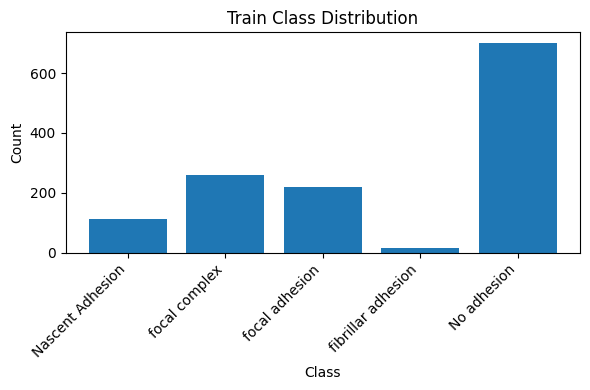

In [47]:

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    df_clean[target_col].map(fa_label_to_id),
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Train Class Distribution")

plt.tight_layout()
plt.show()


In [48]:
len(class_names)

5

In [49]:
def plot_cm(y_val, y_pred,class_names,method_str ):
    cm = confusion_matrix(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)

    class_names = class_names
    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(np.sqrt(cm[:len(class_names),:len(class_names)]), cmap="Blues",vmax=np.sqrt(cm).max()*(0.8))

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{method_str} CM on Val set, ACC={acc:.2f}")
    
    # annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [50]:
!pip install xgboost

In [51]:
import xgboost as xgb
from xgboost import XGBClassifier

# K = number of classes (optional if y is 0..K-1; XGBoost often infers it)
# K = len(np.unique(y_train))

clf = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",      # fast CPU histogram method
    objective="multi:softprob",
    eval_metric="mlogloss",  # or "merror"
    n_jobs=-1,
    random_state=42,
    # num_class=K,          # uncomment if needed
    early_stopping_rounds=100,
)

clf.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val],
    verbose=False,
)

from sklearn.metrics import roc_auc_score, accuracy_score

proba = clf.predict_proba(X_val)  # (n_samples, n_classes)
xgb_val_pred  = clf.predict(X_val)

auc_ovr = roc_auc_score(y_val, proba, multi_class="ovr", average="macro")
acc = accuracy_score(y_val, xgb_val_pred)

print("AUC OVR macro:", auc_ovr)
print("Acc:", acc)

AUC OVR macro: 0.667508688557019
Acc: 0.6030534351145038


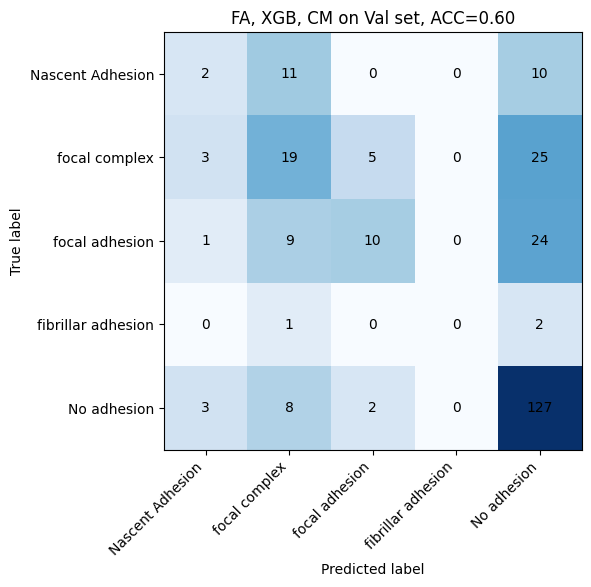

In [52]:
plot_cm(y_val, xgb_val_pred,classification_label_order[:-1], "FA, XGB," )

In [53]:
!pip install lightgbm

In [54]:
y_train_Position

4       1
244     2
94      2
1079    0
1093    3
       ..
1035    3
550     0
953     2
441     0
1305    1
Name: Position, Length: 1048, dtype: int64

In [55]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

lightgbm_clf_Position = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
)

lightgbm_clf_Position.fit(
    X_train, y_train_Position,
    sample_weight=w_train,
    eval_set=[(X_val, y_val_Position)],    
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)
pred_proba_Position = lightgbm_clf_Position.predict_proba(X_val)[:, 1]
pred_label_Position = lightgbm_clf_Position.predict(X_val)

lightgbm_val_pred_Position = lightgbm_clf_Position.predict(X_val)
print("Acc:", accuracy_score(y_val_Position, lightgbm_val_pred_Position))

joblib.dump(lightgbm_clf_Position, "../../results/pax_AE_lat8_FA_lightgbm_clf_Position_iter2.joblib")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -1.836645
[LightGBM] [Info] Start training from score -1.143498
[LightGBM] [Info] Start training from score -1.425210
[LightGBM] [Info] Start training from score -1.277885
[LightGBM] [Info] Start training from score -5.856027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


['../../results/pax_AE_lat8_FA_lightgbm_clf_Position_iter2.joblib']

In [63]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

lightgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
)

lightgbm_clf.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],    
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)
pred_proba = lightgbm_clf.predict_proba(X_val)[:, 1]
pred_label = lightgbm_clf.predict(X_val)

lightgbm_val_pred = lightgbm_clf.predict(X_val)
print("Acc:", accuracy_score(y_val, lightgbm_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, lightgbm_val_pred))

print("Accuracy:", accuracy_score(y_val, lightgbm_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, lightgbm_val_pred))
print("Macro F1:", f1_score(y_val, lightgbm_val_pred, average="macro"))
print("Weighted F1:", f1_score(y_val, lightgbm_val_pred, average="weighted"))


import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

proba = lightgbm_clf.predict_proba(X_val)   # shape [N, C]

# class priors from training labels
classes, counts = np.unique(y_train, return_counts=True)
priors = counts / counts.sum()

for tau in [0.0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    adjusted_scores = np.log(proba + 1e-12) - tau * np.log(priors + 1e-12)
    pred_adj = classes[np.argmax(adjusted_scores, axis=1)]

    print(f"\nTau = {tau}")
    print("Accuracy:", accuracy_score(y_val, pred_adj))
    print("Balanced Accuracy:", balanced_accuracy_score(y_val, pred_adj))
    print("Macro F1:", f1_score(y_val, pred_adj, average="macro"))
    print("Weighted F1:", f1_score(y_val, pred_adj, average="weighted"))


joblib.dump(lightgbm_clf, "../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2.joblib")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -2.454829
[LightGBM] [Info] Start training from score -1.617101
[LightGBM] [Info] Start training from score -1.784155
[LightGBM] [Info] Start training from score -4.389690
[LightGBM] [Info] Start training from score -0.624918
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 1.01913
Acc: 0.6106870229007634

Classification Report:
              precision    recall  f1-score   

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py

['../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2.joblib']

In [64]:
import numpy as np
import joblib
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

lightgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
)

lightgbm_clf.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)

# standard probabilities
pred_proba = lightgbm_clf.predict_proba(X_val)

# class priors from training set
classes, counts = np.unique(y_train, return_counts=True)
priors = counts / counts.sum()

# tuned on validation
tau = 0.2

adjusted_scores = np.log(pred_proba + 1e-12) - tau * np.log(priors + 1e-12)
pred_label = classes[np.argmax(adjusted_scores, axis=1)]

print("Accuracy:", accuracy_score(y_val, pred_label))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, pred_label))
print("Macro F1:", f1_score(y_val, pred_label, average="macro"))
print("Weighted F1:", f1_score(y_val, pred_label, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_val, pred_label))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, pred_label))

joblib.dump(
    {
        "model": lightgbm_clf,
        "classes": classes,
        "priors": priors,
        "tau": tau,
    },
    "../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2_with_tau.joblib"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -2.454829
[LightGBM] [Info] Start training from score -1.617101
[LightGBM] [Info] Start training from score -1.784155
[LightGBM] [Info] Start training from score -4.389690
[LightGBM] [Info] Start training from score -0.624918
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 1.01913
Accuracy: 0.6106870229007634
Balanced Accuracy: 0.3440789645137471
Macro F1: 0.3526396872463432
Weighted F1: 0.5762832312668006

Classification Report:
      

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being 

['../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2_with_tau.joblib']

In [62]:
import numpy as np
import joblib
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils import resample


# =========================================================
# 1. Optional: oversample minority classes in training set
# =========================================================
def oversample_minority_classes(X, y, sample_weight=None, random_state=42, target="median"):
    """
    Oversample minority classes to reduce imbalance.

    target:
        - "median": each class up to median class count
        - "max": each class up to majority class count
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if sample_weight is None:
        sample_weight = np.ones(len(y), dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)

    classes, counts = np.unique(y, return_counts=True)

    if target == "max":
        target_count = counts.max()
    elif target == "median":
        target_count = int(np.median(counts))
        target_count = max(target_count, counts.min())
    else:
        raise ValueError("target must be 'median' or 'max'")

    X_parts, y_parts, w_parts = [], [], []

    for cls, count in zip(classes, counts):
        idx = np.where(y == cls)[0]
        X_cls = X[idx]
        y_cls = y[idx]
        w_cls = sample_weight[idx]

        if count < target_count:
            X_up, y_up, w_up = resample(
                X_cls, y_cls, w_cls,
                replace=True,
                n_samples=target_count,
                random_state=random_state
            )
            X_parts.append(X_up)
            y_parts.append(y_up)
            w_parts.append(w_up)
        else:
            X_parts.append(X_cls)
            y_parts.append(y_cls)
            w_parts.append(w_cls)

    X_new = np.concatenate(X_parts, axis=0)
    y_new = np.concatenate(y_parts, axis=0)
    w_new = np.concatenate(w_parts, axis=0)

    perm = np.random.RandomState(random_state).permutation(len(y_new))
    return X_new[perm], y_new[perm], w_new[perm]


# =========================================================
# 2. Build class-balanced sample weights
# =========================================================
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
soft_weights = np.sqrt(raw_weights)
class_weight_dict = dict(zip(classes, soft_weights))

cw_train = np.array([class_weight_dict[y] for y in y_train], dtype=float)
final_w_train = np.asarray(w_train, dtype=float) * cw_train



# classes = np.unique(y_train)

# class_weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=y_train
# )

# class_weight_dict = dict(zip(classes, class_weights))
# print("Class weights:", class_weight_dict)

# # Map each training sample to its class weight
# cw_train = np.array([class_weight_dict[y] for y in y_train], dtype=float)

# # Combine with your existing sample weights if w_train already has meaning
# # (e.g. confidence / importance weights). If not, just use cw_train.
# final_w_train = cw_train * np.asarray(w_train, dtype=float)

# # Optional: clip extreme weights for stability
# final_w_train = np.clip(final_w_train, 0.1, 10.0)


# =========================================================
# 3. Optional oversampling
#    Start with target="median" for a milder correction.
# =========================================================
USE_OVERSAMPLING = False

if USE_OVERSAMPLING:
    X_train_fit, y_train_fit, w_train_fit = oversample_minority_classes(
        X_train, y_train, sample_weight=final_w_train, target="median", random_state=42
    )
else:
    X_train_fit, y_train_fit, w_train_fit = X_train, y_train, final_w_train


# =========================================================
# 4. Train LightGBM
# =========================================================
lightgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
    # You can also try: max_depth=6, min_child_samples=20
    # to reduce overconfident majority collapse.
)

lightgbm_clf.fit(
    X_train_fit,
    y_train_fit,
    sample_weight=w_train_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)


# =========================================================
# 5. Prediction and evaluation
# =========================================================
pred_label = lightgbm_clf.predict(X_val)
pred_proba = lightgbm_clf.predict_proba(X_val)   # shape: [N, num_classes]

print("Accuracy:", accuracy_score(y_val, pred_label))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, pred_label))
print("Macro F1:", f1_score(y_val, pred_label, average="macro"))
print("Weighted F1:", f1_score(y_val, pred_label, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_val, pred_label))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, pred_label))

joblib.dump(
    lightgbm_clf,
    "../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_weighted_iter2.joblib"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -1.916241
[LightGBM] [Info] Start training from score -1.497377
[LightGBM] [Info] Start training from score -1.580904
[LightGBM] [Info] Start training from score -2.883671
[LightGBM] [Info] Start training from score -1.001286
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid_0's multi_logloss: 1.02591
Accuracy: 0.583969465648855
Balanced Accuracy: 0.32684055075359425
Macro F1: 0.332490760596797
Weighted F1: 0.5565084024496304

Classification Report:
       

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

['../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_weighted_iter2.joblib']

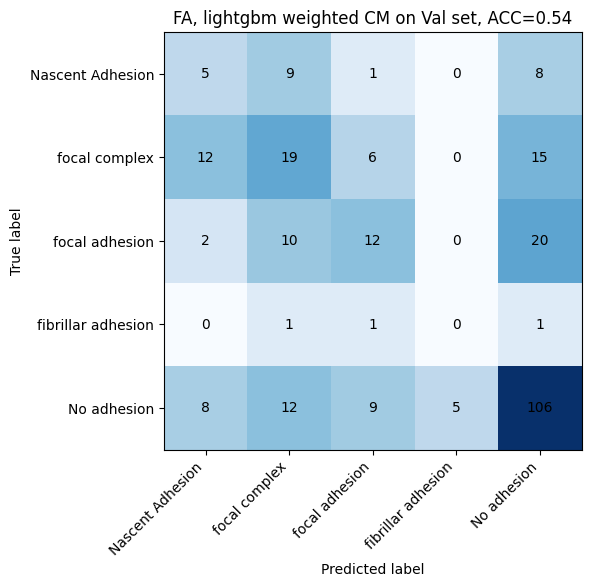

InvalidParameterError: The 'y_pred' parameter of confusion_matrix must be an array-like. Got None instead.

In [58]:
plot_cm(y_val, plot_cm(y_val, pred_label,classification_label_order[:-1], "FA, lightgbm weighted" ),classification_label_order[:-1], "FA, lightgbm" )

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

gb_y_pred = gb.predict(X_val)

              precision    recall  f1-score   support

           0       0.67      0.09      0.15        23
           1       0.41      0.13      0.20        52
           2       0.61      0.39      0.47        44
           3       0.00      0.00      0.00         3
           4       0.60      0.92      0.73       140

    accuracy                           0.59       262
   macro avg       0.46      0.31      0.31       262
weighted avg       0.56      0.59      0.52       262



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


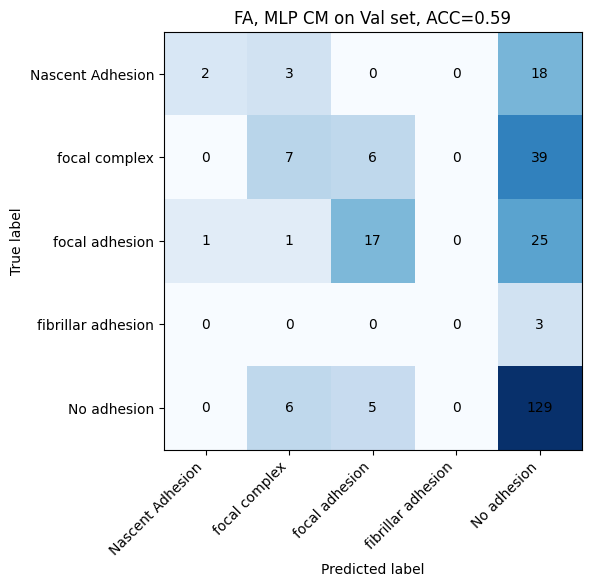

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    activation='relu',
    solver='adam',
    learning_rate_init=0.05,
    max_iter=300,
    random_state=42
)
mlp.fit(X_train, y_train)

mlp_y_pred = mlp.predict(X_val)
print(classification_report(y_val, mlp_y_pred))
plot_cm(y_val, mlp_y_pred,classification_label_order[:-1], "FA, MLP" )

In [ ]:

hgb_clf = HistGradientBoostingClassifier(random_state=0)
hgb_clf.fit(X_train, y_train, sample_weight=w_train)
from sklearn.metrics import classification_report

hgb_y_pred = hgb_clf.predict(X_val)
print(classification_report(y_val, hgb_y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.36      0.33      0.34        52
           2       0.67      0.36      0.47        44
           3       0.00      0.00      0.00         3
           4       0.68      0.87      0.76       140

    accuracy                           0.59       262
   macro avg       0.34      0.31      0.32       262
weighted avg       0.55      0.59      0.55       262



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


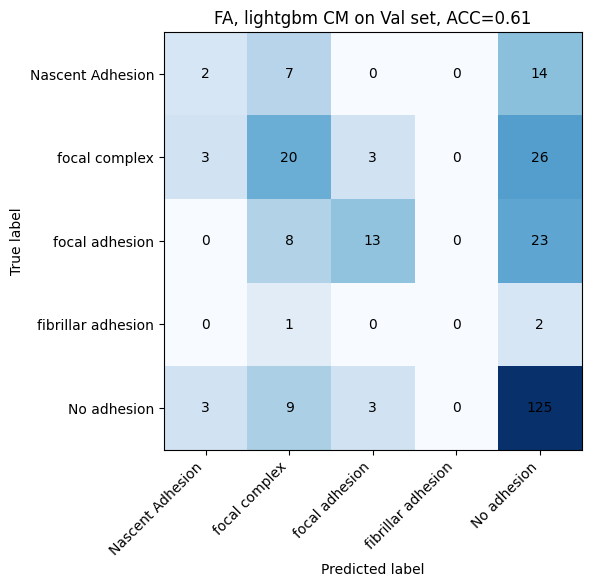

In [ ]:
plot_cm(y_val, lightgbm_val_pred,classification_label_order[:-1], "FA, lightgbm" )

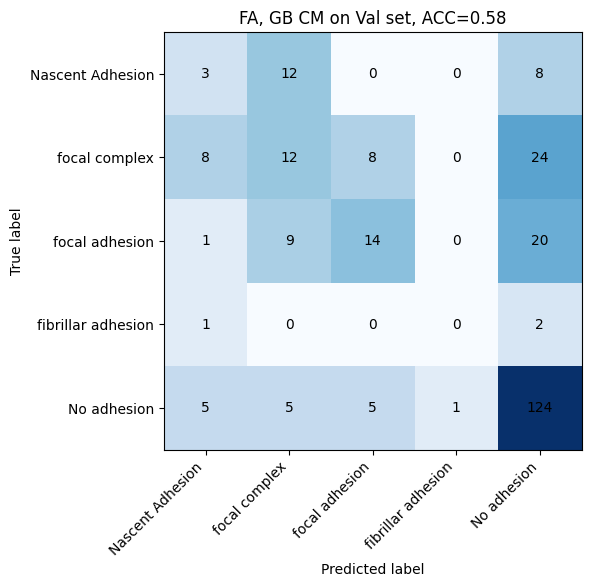

In [ ]:
plot_cm(y_val, gb_y_pred,classification_label_order[:-1], "FA, GB" )

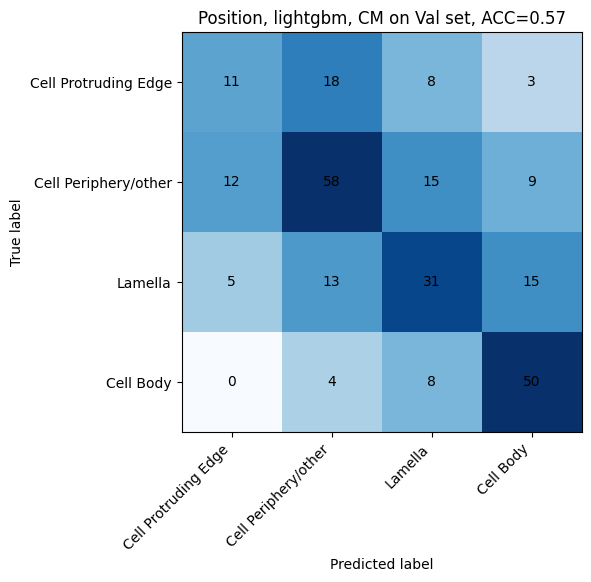

In [ ]:
plot_cm(y_val_Position, lightgbm_val_pred_Position, position_label_order[:-1], "Position, lightgbm," )


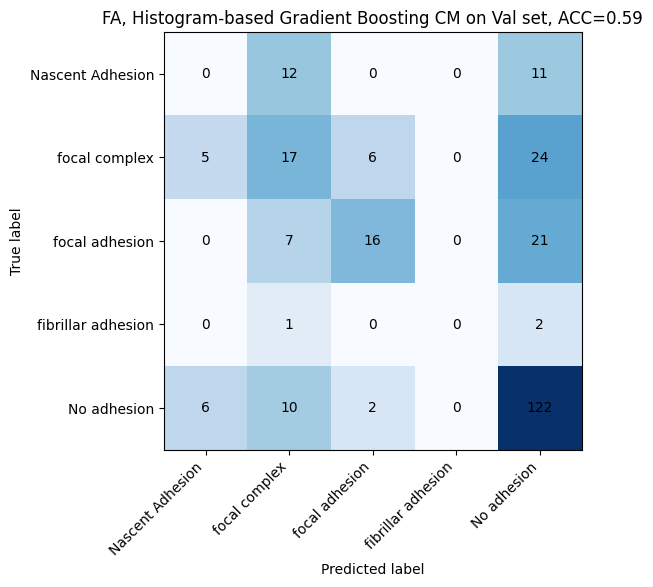

In [ ]:
plot_cm(y_val, hgb_y_pred,classification_label_order[:-1], "FA, Histogram-based Gradient Boosting" )


In [ ]:
import shutil

In [ ]:
def copy_with_prefix(image_folder: str, out_folder: str, prefix_str: str):
    os.makedirs(out_folder, exist_ok=True)

    exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    for name in os.listdir(image_folder):
        if not name.lower().endswith(exts):
            continue

        src = os.path.join(image_folder, name)

        # avoid double-prefixing
        dst_name = name if name.startswith(prefix_str) else prefix_str+f"{name}"
        dst = os.path.join(out_folder, dst_name)

        shutil.copy2(src, dst)

In [ ]:
bundle = joblib.load("../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2_with_tau.joblib")

model = bundle["model"]
classes = bundle["classes"]
priors = bundle["priors"]
tau = bundle["tau"]

proba = model.predict_proba(X_test)
adjusted_scores = np.log(proba + 1e-12) - tau * np.log(priors + 1e-12)
pred = classes[np.argmax(adjusted_scores, axis=1)]

In [68]:
patch_label_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group', 'unique_ID'],
      dtype='object')

In [ ]:
all_pred_df = predict_all_samples(patch_label_df, feature_cols, lightgbm_clf, 'FA_pred')

In [69]:
import joblib
lat_features = [
    "lat_d0",
    "lat_d1",
    "lat_d2",
    "lat_d3",
    "lat_d4",
    "lat_d5",
    "lat_d6",
    "lat_d7",
]

bundle = joblib.load("../../results/pax_AE_lat8_FA_lightgbm_clf_classifier_iter2_with_tau.joblib")

pred_df = predict_all_samples(
    patch_label_df=patch_label_df,
    lat_features=lat_features,
    clf_or_bundle=bundle,
    pred_col_name="pred_label",
    use_tau_adjustment=True
)

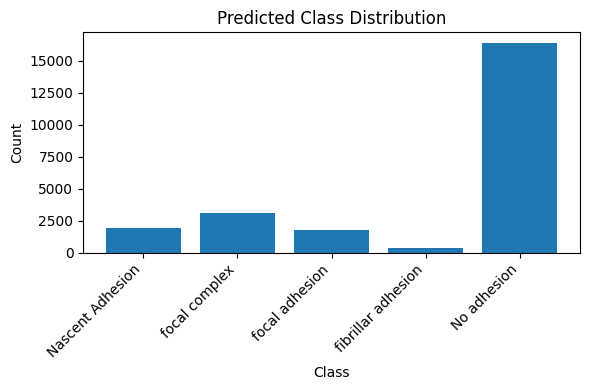

In [70]:

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    all_pred_df['FA_pred'],
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


In [ ]:
control_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_0948"
ycomp_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_1005"


In [ ]:
# copy_with_prefix(control_folder, "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy", "control-")
# copy_with_prefix(ycomp_folder, "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy", "ycomp-")

In [ ]:
big_image_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy"

In [ ]:
import tifffile

In [ ]:
n_classes = 5
for split in ["train", "val"]:
    for g in range(n_classes):
        for p in range(n_classes):
            os.makedirs(os.path.join(root_dir, split, f"gt{g}_pred{p}"), exist_ok=True)


In [ ]:
for index, row in df_clean.iterrows():
    image_path = os.path.join(big_image_folder, row['unique_ID'])
    # image = tifffile.imread(image_path)
    lat_feature = row[feature_cols].to_numpy()
    this_pred_label = lightgbm_clf.predict(lat_feature)
    manual_label = row['classification'].map(fa_label_to_id)
    print([this_pred_label, manual_label])
    new_folder = os.path.join(root_dir, split, f"gt{manual_label}_pred{this_pred_label}")
    shutil.copy(image_path, os.path.join(new_folder,row['unique_ID']))
    

NameError: name 'lightgbm_clf' is not defined

In [ ]:

# # Identify "test" images = those present in folder but not listed in CSV
# csv_images = set(df["image"].tolist())
# all_images = {
#     f for f in os.listdir(image_folder)
#     if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"))
# }
# test_images = sorted(all_images - csv_images)

# base = os.path.join(image_folder, f"predictions_{timestamp}")
# os.makedirs(base, exist_ok=True)


for row in df_clean:
    print(row)

model.eval()

def run_inference(img_path):
    image = Image.open(img_path).convert("RGB")
    image_t = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(image_t)
        probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).item()
    n_classes = probs.shape[1]
    return pred, n_classes

# Determine number of classes once (from first available image)
probe_img = None
if len(train_indices) > 0:
    probe_img = os.path.join(image_folder, df.loc[train_indices[0], "image"])
elif len(val_indices) > 0:
    probe_img = os.path.join(image_folder, df.loc[val_indices[0], "image"])
elif len(test_images) > 0:
    probe_img = os.path.join(image_folder, test_images[0])

if probe_img is None:
    raise ValueError("No images found to infer number of classes.")

_, n_classes = run_inference(probe_img)

# Create directories for all gt/pred pairs for train/val
for split in ["train", "val"]:
    for g in range(n_classes):
        for p in range(n_classes):
            os.makedirs(os.path.join(base, split, f"gt{g}_pred{p}"), exist_ok=True)

# Create directories for test by predicted class
for p in range(n_classes):
    os.makedirs(os.path.join(base, "test", f"pred{p}"), exist_ok=True)

records = []

for split_name, indices in {"train": train_indices, "val": val_indices}.items():
    print(f"[INFO] Processing {split_name}...")
    for idx in indices:
        img_name = df.loc[idx, "image"]
        gt_label = int(df.loc[idx, "label"])
        img_path = os.path.join(image_folder, img_name)

        pred, _ = run_inference(img_path)

        cat = f"gt{gt_label}_pred{pred}"
        out_name = img_name  # keep original name; change if you want prefixes

        shutil.copy(img_path, os.path.join(base, split_name, cat, out_name))

        records.append({
            "image": img_name,
            "split": split_name,
            "gt_label": gt_label,
            "pred": pred,
            "category": cat,
        })

print("[INFO] Processing test...")
for img_name in test_images:
    img_path = os.path.join(image_folder, img_name)
    pred, _ = run_inference(img_path)

    cat = f"pred{pred}"
    out_name = img_name
    shutil.copy(img_path, os.path.join(base, "test", cat, out_name))

    records.append({
        "image": img_name,
        "split": "test",
        "gt_label": None,
        "pred": pred,
        "category": cat,
    })

out_csv = os.path.join(base, "predictions_multiclass.csv")
pd.DataFrame(records).to_csv(out_csv, index=False)
print(f"/n[DONE] Predictions saved to: {base}")
print(f"[DONE] CSV written to: {out_csv}")